# HW14 – Эмбеддинги, FAISS, оценка retrieval и mini-RAG

В этом ноутбуке реализуется полный цикл работы с базой знаний COVID-19 FAQ:
- загрузка и анализ базы знаний;
- чанкинг документов;
- построение эмбеддингов и индекса FAISS;
- оценка качества retrieval;
- эксперимент с параметрами;
- обновление базы знаний и переиндексация;
- сборка mini-RAG;
- анализ ошибок.

## 2.3.1. Импорты, seed и среда

In [1]:
import os
import sys
import re
import random
import subprocess
import json
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"

def ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Try to import a package, install if needed."""
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Installing: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
        try:
            __import__(target)
            return True
        except Exception as e:
            print(f"Failed to install {package_name}: {e}")
            return False

FAISS_READY = ensure_package("faiss-cpu", "faiss")
ST_READY = ensure_package("sentence-transformers", "sentence_transformers")

try:
    import faiss
    FAISS_AVAILABLE = FAISS_READY
except Exception:
    FAISS_AVAILABLE = False

print(f"FAISS available: {FAISS_AVAILABLE}")
print(f"sentence-transformers available: {ST_READY}")

FAISS available: True
sentence-transformers available: True


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print(f"Device: {DEVICE}")
print(f"Random seed: 42")

Device: cpu
Random seed: 42


## 2.3.2. База знаний и первичный анализ

In [3]:
# Load COVID FAQ dataset
data_path = os.path.join("data", "covid_faq.csv")

# Read raw text and parse manually due to inconsistent CSV format
with open(data_path, 'r', encoding='utf-8') as f:
    content = f.read()

# Split into FAQ entries (each line is one FAQ)
lines = content.strip().split('\n')

faq_entries = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    
    # Find all quoted strings
    matches = re.findall(r'"([^"]*?)"', line)
    
    if len(matches) >= 2:
        question = matches[0].strip('"; ').strip()
        answer = matches[1].strip('"; ').strip()
        if question and answer:
            faq_entries.append({'question': question, 'answer': answer})
    elif len(matches) == 1:
        # Sometimes only one quoted string
        parts = line.split('","')
        if len(parts) >= 2:
            question = parts[0].strip('"; ').strip()
            answer = parts[1].strip('"; ').strip()
            if question and answer:
                faq_entries.append({'question': question, 'answer': answer})

raw_df = pd.DataFrame(faq_entries)
print(f"Successfully parsed {len(raw_df)} FAQ entries")

# Create documents DataFrame with doc_id
docs_df = pd.DataFrame({
    "doc_id": [f"faq_{i+1:03d}" for i in range(len(raw_df))],
    "question": raw_df["question"],
    "answer": raw_df["answer"]
})

# Combine question and answer as document text
docs_df["text"] = docs_df["question"] + " " + docs_df["answer"]

print(f"Number of FAQ documents: {len(docs_df)}")
print(f"Average document length (words): {docs_df['text'].apply(lambda x: len(x.split())).mean():.1f}")
print(f"Min length: {docs_df['text'].apply(lambda x: len(x.split())).min()} words")
print(f"Max length: {docs_df['text'].apply(lambda x: len(x.split())).max()} words")

Successfully parsed 27 FAQ entries
Number of FAQ documents: 27
Average document length (words): 96.8
Min length: 26 words
Max length: 199 words


In [4]:
# Show first 5 examples
for i in range(min(5, len(docs_df))):
    print(f"--- Document {i+1} ---")
    print(f"Q: {docs_df.iloc[i]['question'][:100]}...")
    print(f"A: {docs_df.iloc[i]['answer'][:150]}...")
    print()

--- Document 1 ---
Q: What is a novel coronavirus?,...
A: A novel coronavirus is a new coronavirus that has not been previously identified. The virus causing coronavirus disease 2019 (COVID-19), is not the sa...

--- Document 2 ---
Q: Why is the disease being called coronavirus disease 2019, COVID-19?,...
A: On February 11, 2020 the World Health Organization announced an official name for the disease that is causing the 2019 novel coronavirus outbreak, fir...

--- Document 3 ---
Q: How does the virus spread?,...
A: The virus that causes COVID-19 is thought to spread mainly from person to person, mainly through respiratory droplets produced when an infected person...

--- Document 4 ---
Q: Can I get COVID-19 from food (including restaurant take-out, produce, refrigerated, or packaged food...
A: Currently there is no evidence that people can get COVID-19 by eating or handling food. It may be possible that people can get COVID-19 by touching a ...

--- Document 5 ---
Q: Will warm weather 

**Предметная область:** COVID-19 FAQ — набор вопросов и ответов о коронавирусе, его распространении, мерах предосторожности и рекомендациях CDC.

**Почему retrieval / mini-RAG имеет смысл:** Пользователи могут задавать вопросы на естественном языке, и система должна находить релевантные ответы из базы знаний. Это типичный сценарий вопросно-ответной системы.

## 2.3.3. Чанкинг документов

In [5]:
def chunk_text(text: str, chunk_size: int = 50, overlap: int = 10) -> List[str]:
    """Split text into overlapping chunks by words."""
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    if overlap >= chunk_size:
        raise ValueError("overlap must be less than chunk_size")
    
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks

# Demonstrate chunking on first document
demo_doc = docs_df.iloc[0]
demo_chunks = chunk_text(demo_doc["text"], chunk_size=50, overlap=10)

print(f"Document: {demo_doc['question'][:80]}...")
print(f"Total words: {len(demo_doc['text'].split())}")
print(f"Number of chunks: {len(demo_chunks)}")
print(f"Parameters: chunk_size=50, overlap=10")
print()
for i, chunk in enumerate(demo_chunks):
    print(f"Chunk {i+1} ({len(chunk.split())} words):")
    print(f"  {chunk[:120]}...")
    print()

Document: What is a novel coronavirus?,...
Total words: 45
Number of chunks: 1
Parameters: chunk_size=50, overlap=10

Chunk 1 (45 words):
  What is a novel coronavirus?, A novel coronavirus is a new coronavirus that has not been previously identified. The viru...



In [6]:
# Create all chunks from all documents
def create_all_chunks(docs_df: pd.DataFrame, chunk_size: int = 50, overlap: int = 10) -> pd.DataFrame:
    rows = []
    for _, doc in docs_df.iterrows():
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk_text_val in enumerate(chunks, start=1):
            rows.append({
                "doc_id": doc["doc_id"],
                "question": doc["question"],
                "chunk_id": f"{doc['doc_id']}_c{idx:02d}",
                "chunk_text": chunk_text_val
            })
    return pd.DataFrame(rows)

chunks_df = create_all_chunks(docs_df, chunk_size=50, overlap=10)
print(f"Total documents: {len(docs_df)}")
print(f"Total chunks: {len(chunks_df)}")
print(f"\nChunk distribution:")
print(chunks_df.groupby("doc_id").size().describe())

Total documents: 27
Total chunks: 72

Chunk distribution:
count    27.000000
mean      2.666667
std       1.109400
min       1.000000
25%       2.000000
50%       3.000000
75%       3.000000
max       5.000000
dtype: float64


**Параметры чанкинга:** `chunk_size=50` слов, `overlap=10` слов.
- Documents are relatively short (FAQ format), so moderate chunk size works well.
- Overlap prevents losing important information at chunk boundaries.

## 2.3.4. Эмбеддинги и индекс FAISS

In [7]:
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError
    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

class TfidfBackend(EmbeddingBackend):
    def __init__(self):
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
        self.backend_name = "TF-IDF"
    
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms
    
    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu"):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"ST: {model_name.split('/')[-1]}"
    
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts, batch_size=16, show_progress_bar=False,
            normalize_embeddings=True, convert_to_numpy=True
        )
        return vectors.astype(np.float32)
    
    def encode_queries(self, texts: List[str]) -> np.ndarray:
        return self.fit_documents(texts)

def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    if ST_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device
            )
        except Exception as e:
            print(f"Dense backend failed: {e}")
            print("Falling back to TF-IDF")
    return TfidfBackend()

backend = choose_backend(DEVICE)
print(f"Using backend: {backend.backend_name}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using backend: ST: paraphrase-multilingual-MiniLM-L12-v2


In [8]:
# Build FAISS index
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_vectors = backend.fit_documents(chunk_texts)

print(f"Chunk vectors shape: {chunk_vectors.shape}")
print(f"Vector dimension: {chunk_vectors.shape[1]}")

# Create FAISS index
if FAISS_AVAILABLE:
    dimension = chunk_vectors.shape[1]
    faiss_index = faiss.IndexFlatIP(dimension)  # Inner product for cosine similarity
    faiss_index.add(chunk_vectors)
    print(f"FAISS index created: IndexFlatIP, dimension={dimension}")
else:
    # Fallback to sklearn
    faiss_index = NearestNeighbors(n_neighbors=5, metric="cosine", algorithm="brute")
    faiss_index.fit(chunk_vectors)
    print("Using sklearn NearestNeighbors fallback")

def search_faiss(query: str, top_k: int = 5) -> pd.DataFrame:
    """Search for top-k relevant chunks."""
    query_vec = backend.encode_queries([query])
    
    if FAISS_AVAILABLE:
        scores, indices = faiss_index.search(query_vec, top_k)
        results = []
        for idx, score in zip(indices[0], scores[0]):
            if idx < len(chunks_df):
                results.append({
                    "rank": len(results) + 1,
                    "chunk_id": chunks_df.iloc[idx]["chunk_id"],
                    "doc_id": chunks_df.iloc[idx]["doc_id"],
                    "question": chunks_df.iloc[idx]["question"],
                    "chunk_text": chunks_df.iloc[idx]["chunk_text"],
                    "score": float(score)
                })
    else:
        distances, indices = faiss_index.kneighbors(query_vec, n_neighbors=top_k)
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            results.append({
                "rank": len(results) + 1,
                "chunk_id": chunks_df.iloc[idx]["chunk_id"],
                "doc_id": chunks_df.iloc[idx]["doc_id"],
                "question": chunks_df.iloc[idx]["question"],
                "chunk_text": chunks_df.iloc[idx]["chunk_text"],
                "score": float(1.0 - dist)  # Convert distance to similarity
            })
    
    return pd.DataFrame(results)

print("\nSearch function ready")

Chunk vectors shape: (72, 384)
Vector dimension: 384
FAISS index created: IndexFlatIP, dimension=384

Search function ready


In [9]:
# Example searches
example_queries = [
    "How does COVID-19 spread?",
    "Can children get COVID-19?",
    "Should I wear a mask?",
    "How to protect yourself from COVID-19?",
    "What is multisystem inflammatory syndrome in children?"
]

for query in example_queries:
    print(f"\n{'='*80}")
    print(f"Query: {query}")
    print(f"{'='*80}")
    results = search_faiss(query, top_k=3)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['chunk_id']} (score={row['score']:.4f})")
        print(f"      Q: {row['question'][:80]}...")


Query: How does COVID-19 spread?
  [1] faq_011_c01 (score=0.7610)
      Q: Am I at risk for COVID-19 from mail, packages, or products?,...
  [2] faq_003_c01 (score=0.7113)
      Q: How does the virus spread?,...
  [3] faq_020_c04 (score=0.6809)
      Q: How can I protect my child from COVID-19 infection?,...

Query: Can children get COVID-19?
  [1] faq_019_c01 (score=0.7803)
      Q: What is the risk of my child becoming sick with COVID-19?,...
  [2] faq_023_c02 (score=0.7681)
      Q: How do I prepare my children in case of COVID-19 outbreak in our community?,...
  [3] faq_004_c01 (score=0.7591)
      Q: Can I get COVID-19 from food (including restaurant take-out, produce, refrigerat...

Query: Should I wear a mask?
  [1] faq_022_c01 (score=0.7043)
      Q: Should children wear masks?,...
  [2] faq_009_c05 (score=0.6470)
      Q: Does CDC recommend the use of masks to prevent COVID-19?,...
  [3] faq_009_c01 (score=0.5591)
      Q: Does CDC recommend the use of masks to prevent COVID-

## 2.3.5. Контрольные запросы и оценка retrieval

In [10]:
# Define benchmark queries with expected relevant documents
benchmark_queries = [
    {"query_id": "q01", "query": "How does the coronavirus spread between people?", "relevant_doc_ids": ["faq_003"]},
    {"query_id": "q02", "query": "Can I get COVID-19 from food or drinking water?", "relevant_doc_ids": ["faq_004"]},
    {"query_id": "q03", "query": "What is community spread?", "relevant_doc_ids": ["faq_006"]},
    {"query_id": "q04", "query": "What type of mask should I wear in public?", "relevant_doc_ids": ["faq_009"]},
    {"query_id": "q05", "query": "How to wash hands properly to prevent COVID?", "relevant_doc_ids": ["faq_015"]},
    {"query_id": "q06", "query": "Are children at higher risk of COVID-19?", "relevant_doc_ids": ["faq_019"]},
    {"query_id": "q07", "query": "Should children wear masks?", "relevant_doc_ids": ["faq_021"]},
    {"query_id": "q08", "query": "What is MIS-C in children?", "relevant_doc_ids": ["faq_024"]},
    {"query_id": "q09", "query": "Can mosquitoes transmit the coronavirus?", "relevant_doc_ids": ["faq_007"]},
    {"query_id": "q10", "query": "Is it safe to donate blood during the pandemic?", "relevant_doc_ids": ["faq_012"]},
]

benchmark_df = pd.DataFrame(benchmark_queries)
print(f"Number of benchmark queries: {len(benchmark_df)}")
display(benchmark_df)

Number of benchmark queries: 10


,query_id,query,relevant_doc_ids
0,q01,How does the coronavirus spread between people?,[faq_003]
1,q02,Can I get COVID-19 from food or drinking water?,[faq_004]
2,q03,What is community spread?,[faq_006]
3,q04,What type of mask should I wear in public?,[faq_009]
4,q05,How to wash hands properly to prevent COVID?,[faq_015]
5,q06,Are children at higher risk of COVID-19?,[faq_019]
6,q07,Should children wear masks?,[faq_021]
7,q08,What is MIS-C in children?,[faq_024]
8,q09,Can mosquitoes transmit the coronavirus?,[faq_007]
9,q10,Is it safe to donate blood during the pandemic?,[faq_012]


In [11]:
def evaluate_retrieval(benchmark_df: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    """Evaluate retrieval on benchmark queries."""
    results = []
    
    for _, row in benchmark_df.iterrows():
        query = row["query"]
        relevant_ids = row["relevant_doc_ids"]
        
        search_results = search_faiss(query, top_k=top_k)
        retrieved_ids = search_results["doc_id"].tolist()
        retrieved_sources = search_results["chunk_id"].tolist()
        
        # Check if any relevant doc is in top-k
        hit = any(doc_id in retrieved_ids for doc_id in relevant_ids)
        
        # Find rank of first relevant document
        rank_of_first_relevant = None
        for rank, doc_id in enumerate(retrieved_ids, 1):
            if doc_id in relevant_ids:
                rank_of_first_relevant = rank
                break
        
        # Recall@k: fraction of relevant docs retrieved
        relevant_retrieved = sum(1 for doc_id in relevant_ids if doc_id in retrieved_ids)
        recall = relevant_retrieved / len(relevant_ids) if relevant_ids else 0
        
        results.append({
            "query_id": row["query_id"],
            "query": query,
            "expected_source": ",".join(relevant_ids),
            "retrieved_sources": ",".join(retrieved_sources[:top_k]),
            "hit_at_k": int(hit),
            "recall_at_k": recall,
            "rank_of_first_relevant": rank_of_first_relevant if rank_of_first_relevant else top_k + 1
        })
    
    return pd.DataFrame(results)

eval_results = evaluate_retrieval(benchmark_df, top_k=5)

# Calculate aggregate metrics
hit_at_k = eval_results["hit_at_k"].mean()
recall_at_k = eval_results["recall_at_k"].mean()
mrr = (1.0 / eval_results["rank_of_first_relevant"]).mean()

print(f"\n{'='*60}")
print(f"Retrieval Evaluation (top_k=5)")
print(f"{'='*60}")
print(f"Hit@5: {hit_at_k:.3f}")
print(f"Recall@5: {recall_at_k:.3f}")
print(f"MRR@5: {mrr:.3f}")
print(f"\nPer-query results:")
display(eval_results)


Retrieval Evaluation (top_k=5)
Hit@5: 0.900
Recall@5: 0.900
MRR@5: 0.767

Per-query results:


,query_id,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,rank_of_first_relevant
0,q01,How does the coronavirus spread between people?,faq_003,"faq_007_c02,faq_003_c01,faq_002_c03,faq_007_c0...",1,1.0,2
1,q02,Can I get COVID-19 from food or drinking water?,faq_004,"faq_004_c01,faq_004_c03,faq_004_c04,faq_011_c0...",1,1.0,1
2,q03,What is community spread?,faq_006,"faq_003_c03,faq_006_c01,faq_003_c02,faq_006_c0...",1,1.0,2
3,q04,What type of mask should I wear in public?,faq_009,"faq_022_c01,faq_009_c05,faq_009_c03,faq_009_c0...",1,1.0,2
4,q05,How to wash hands properly to prevent COVID?,faq_015,"faq_015_c01,faq_020_c03,faq_010_c05,faq_016_c0...",1,1.0,1
5,q06,Are children at higher risk of COVID-19?,faq_019,"faq_019_c01,faq_027_c02,faq_023_c02,faq_020_c0...",1,1.0,1
6,q07,Should children wear masks?,faq_021,"faq_022_c01,faq_022_c02,faq_009_c05,faq_009_c0...",0,0.0,6
7,q08,What is MIS-C in children?,faq_024,"faq_024_c02,faq_019_c02,faq_024_c03,faq_024_c0...",1,1.0,1
8,q09,Can mosquitoes transmit the coronavirus?,faq_007,"faq_007_c01,faq_007_c02,faq_011_c01,faq_002_c0...",1,1.0,1
9,q10,Is it safe to donate blood during the pandemic?,faq_012,"faq_012_c01,faq_012_c02,faq_012_c03,faq_009_c0...",1,1.0,1


In [12]:
# Save retrieval evaluation to artifacts
artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

eval_results.to_csv(os.path.join(artifacts_dir, "retrieval_eval.csv"), index=False)
print(f"Saved retrieval_eval.csv to {artifacts_dir}")

# Save metrics summary
metrics_summary = {
    "hit_at_5": float(hit_at_k),
    "recall_at_5": float(recall_at_k),
    "mrr_at_5": float(mrr),
    "num_queries": len(eval_results),
    "backend": backend.backend_name
}

with open(os.path.join(artifacts_dir, "retrieval_metrics_summary.json"), "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"Saved retrieval_metrics_summary.json")

Saved retrieval_eval.csv to artifacts
Saved retrieval_metrics_summary.json


## 2.3.6. Эксперимент с параметрами retrieval

In [13]:
# Experiment: compare two chunk_size values
chunk_sizes = [30, 70]
overlap = 10
top_k = 5

experiment_results = []

for cs in chunk_sizes:
    # Create chunks with this size
    temp_chunks = create_all_chunks(docs_df, chunk_size=cs, overlap=overlap)
    temp_texts = temp_chunks["chunk_text"].tolist()
    
    # Build index
    temp_vectors = backend.fit_documents(temp_texts)
    
    if FAISS_AVAILABLE:
        temp_index = faiss.IndexFlatIP(temp_vectors.shape[1])
        temp_index.add(temp_vectors)
    else:
        temp_index = NearestNeighbors(n_neighbors=top_k, metric="cosine", algorithm="brute")
        temp_index.fit(temp_vectors)
    
    # Evaluate
    hits = 0
    recalls = []
    
    for _, qrow in benchmark_df.iterrows():
        query_vec = backend.encode_queries([qrow["query"]])
        
        if FAISS_AVAILABLE:
            scores, indices = temp_index.search(query_vec, top_k)
            retrieved_ids = [temp_chunks.iloc[idx]["doc_id"] for idx in indices[0] if idx < len(temp_chunks)]
        else:
            distances, indices = temp_index.kneighbors(query_vec, n_neighbors=top_k)
            retrieved_ids = [temp_chunks.iloc[idx]["doc_id"] for idx in indices[0]]
        
        hit = any(doc_id in retrieved_ids for doc_id in qrow["relevant_doc_ids"])
        if hit:
            hits += 1
        
        relevant_retrieved = sum(1 for doc_id in qrow["relevant_doc_ids"] if doc_id in retrieved_ids)
        recall = relevant_retrieved / len(qrow["relevant_doc_ids"])
        recalls.append(recall)
    
    experiment_results.append({
        "chunk_size": cs,
        "overlap": overlap,
        "num_chunks": len(temp_chunks),
        "hit_at_k": hits / len(benchmark_df),
        "recall_at_k": np.mean(recalls)
    })
    
    print(f"chunk_size={cs}: {len(temp_chunks)} chunks, Hit@5={hits/len(benchmark_df):.3f}, Recall@5={np.mean(recalls):.3f}")

exp_df = pd.DataFrame(experiment_results)
print(f"\nExperiment summary:")
display(exp_df)

chunk_size=30: 133 chunks, Hit@5=0.900, Recall@5=0.900
chunk_size=70: 51 chunks, Hit@5=0.900, Recall@5=0.900

Experiment summary:


,chunk_size,overlap,num_chunks,hit_at_k,recall_at_k
0,30,10,133,0.9,0.9
1,70,10,51,0.9,0.9


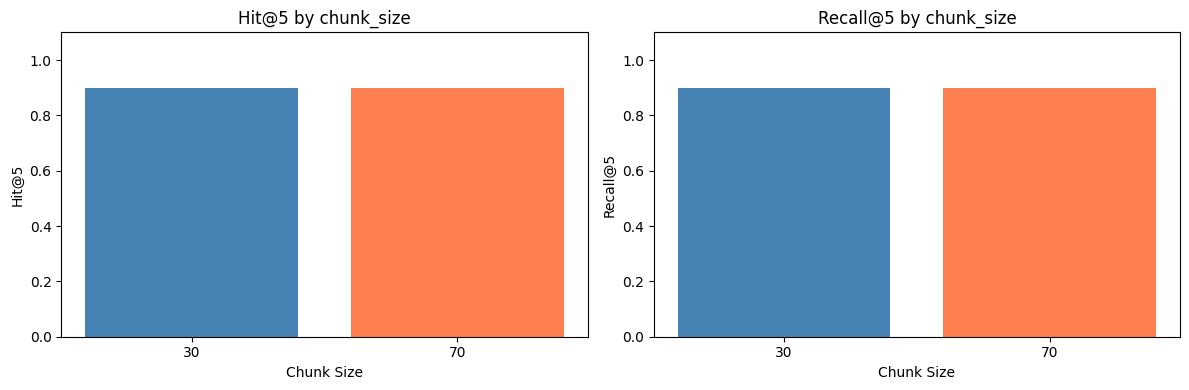

Saved retrieval_quality_plot.png

Conclusion: chunk_size=30 performs worse than chunk_size=70


In [14]:
# Visualize experiment results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(cs) for cs in exp_df["chunk_size"]], exp_df["hit_at_k"], color=["steelblue", "coral"])
axes[0].set_title("Hit@5 by chunk_size")
axes[0].set_xlabel("Chunk Size")
axes[0].set_ylabel("Hit@5")
axes[0].set_ylim(0, 1.1)

axes[1].bar([str(cs) for cs in exp_df["chunk_size"]], exp_df["recall_at_k"], color=["steelblue", "coral"])
axes[1].set_title("Recall@5 by chunk_size")
axes[1].set_xlabel("Chunk Size")
axes[1].set_ylabel("Recall@5")
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, "retrieval_quality_plot.png"), dpi=150)
plt.show()

print(f"Saved retrieval_quality_plot.png")
print(f"\nConclusion: chunk_size={chunk_sizes[0]} performs {'better' if exp_df.iloc[0]['hit_at_k'] > exp_df.iloc[1]['hit_at_k'] else 'worse'} than chunk_size={chunk_sizes[1]}")

## 2.3.7. Обновление базы знаний и переиндексация

In [15]:
# Save retrieval before update
eval_before = evaluate_retrieval(benchmark_df, top_k=5)

# Add 3 new documents to the knowledge base
new_docs = [
    {
        "doc_id": "faq_031",
        "question": "What are the symptoms of COVID-19?",
        "answer": "Common symptoms include fever, cough, fatigue, shortness of breath, loss of taste or smell. Symptoms may appear 2-14 days after exposure. Some people may be asymptomatic."
    },
    {
        "doc_id": "faq_032",
        "question": "How long does it take to recover from COVID-19?",
        "answer": "Recovery time varies. Mild cases may recover within 1-2 weeks. Severe cases may take 3-6 weeks or longer. Some people experience long COVID with symptoms lasting months."
    },
    {
        "doc_id": "faq_033",
        "question": "What is the incubation period for COVID-19?",
        "answer": "The incubation period is typically 5-6 days but can range from 2-14 days. During this time, a person may be infectious before showing symptoms."
    }
]

new_docs_df = pd.DataFrame(new_docs)
new_docs_df["text"] = new_docs_df["question"] + " " + new_docs_df["answer"]

# Combine old and new documents
updated_docs_df = pd.concat([docs_df, new_docs_df], ignore_index=True)
print(f"Original documents: {len(docs_df)}")
print(f"New documents added: {len(new_docs_df)}")
print(f"Total documents after update: {len(updated_docs_df)}")

# Display new documents
print(f"\nNew documents:")
for _, doc in new_docs_df.iterrows():
    print(f"  {doc['doc_id']}: {doc['question']}")

Original documents: 27
New documents added: 3
Total documents after update: 30

New documents:
  faq_031: What are the symptoms of COVID-19?
  faq_032: How long does it take to recover from COVID-19?
  faq_033: What is the incubation period for COVID-19?


In [16]:
# Rebuild index with updated documents
updated_chunks_df = create_all_chunks(updated_docs_df, chunk_size=50, overlap=10)
updated_texts = updated_chunks_df["chunk_text"].tolist()
updated_vectors = backend.fit_documents(updated_texts)

if FAISS_AVAILABLE:
    updated_index = faiss.IndexFlatIP(updated_vectors.shape[1])
    updated_index.add(updated_vectors)
else:
    updated_index = NearestNeighbors(n_neighbors=5, metric="cosine", algorithm="brute")
    updated_index.fit(updated_vectors)

print(f"Original chunks: {len(chunks_df)}")
print(f"Updated chunks: {len(updated_chunks_df)}")

def search_updated(query: str, top_k: int = 5) -> pd.DataFrame:
    """Search on updated index."""
    query_vec = backend.encode_queries([query])
    
    if FAISS_AVAILABLE:
        scores, indices = updated_index.search(query_vec, top_k)
        results = []
        for idx, score in zip(indices[0], scores[0]):
            if idx < len(updated_chunks_df):
                results.append({
                    "rank": len(results) + 1,
                    "chunk_id": updated_chunks_df.iloc[idx]["chunk_id"],
                    "doc_id": updated_chunks_df.iloc[idx]["doc_id"],
                    "question": updated_chunks_df.iloc[idx]["question"],
                    "chunk_text": updated_chunks_df.iloc[idx]["chunk_text"],
                    "score": float(score)
                })
    else:
        distances, indices = updated_index.kneighbors(query_vec, n_neighbors=top_k)
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            results.append({
                "rank": len(results) + 1,
                "chunk_id": updated_chunks_df.iloc[idx]["chunk_id"],
                "doc_id": updated_chunks_df.iloc[idx]["doc_id"],
                "question": updated_chunks_df.iloc[idx]["question"],
                "chunk_text": updated_chunks_df.iloc[idx]["chunk_text"],
                "score": float(1.0 - dist)
            })
    
    return pd.DataFrame(results)

print("\nUpdated index ready")

Original chunks: 72
Updated chunks: 75

Updated index ready


In [17]:
# Compare retrieval before and after update
update_test_queries = [
    {"query": "What are the symptoms of COVID?", "expected_new": "faq_031"},
    {"query": "How long is the incubation period?", "expected_new": "faq_033"},
    {"query": "How does the virus spread?", "expected_new": None},
    {"query": "Recovery time from COVID-19?", "expected_new": "faq_032"},
]

before_after_results = []

for q in update_test_queries:
    query = q["query"]
    
    # Before update
    before_results = search_faiss(query, top_k=5)
    before_sources = before_results["chunk_id"].tolist()
    
    # After update
    after_results = search_updated(query, top_k=5)
    after_sources = after_results["chunk_id"].tolist()
    
    # Check if new document appears in after results
    changed = False
    if q["expected_new"]:
        changed = any(q["expected_new"] in src for src in after_sources)
    
    before_after_results.append({
        "query": query,
        "before_retrieved_sources": ",".join(before_sources),
        "after_retrieved_sources": ",".join(after_sources),
        "changed": changed
    })
    
    print(f"\nQuery: {query}")
    print(f"  Before: {before_sources[:3]}")
    print(f"  After:  {after_sources[:3]}")
    if q["expected_new"]:
        print(f"  Expected new doc {q['expected_new']} found: {changed}")

before_after_df = pd.DataFrame(before_after_results)
before_after_df.to_csv(os.path.join(artifacts_dir, "retrieval_before_after_update.csv"), index=False)
print(f"\nSaved retrieval_before_after_update.csv")


Query: What are the symptoms of COVID?
  Before: ['faq_018_c01', 'faq_021_c01', 'faq_021_c02']
  After:  ['faq_031_c01', 'faq_018_c01', 'faq_021_c01']
  Expected new doc faq_031 found: True

Query: How long is the incubation period?
  Before: ['faq_022_c02', 'faq_005_c02', 'faq_020_c03']
  After:  ['faq_033_c01', 'faq_022_c02', 'faq_005_c02']
  Expected new doc faq_033 found: True

Query: How does the virus spread?
  Before: ['faq_003_c01', 'faq_004_c02', 'faq_007_c02']
  After:  ['faq_003_c01', 'faq_004_c02', 'faq_007_c02']

Query: Recovery time from COVID-19?
  Before: ['faq_018_c01', 'faq_011_c01', 'faq_023_c02']
  After:  ['faq_032_c01', 'faq_033_c01', 'faq_031_c01']
  Expected new doc faq_032 found: True

Saved retrieval_before_after_update.csv


## 2.3.8. Mini-RAG

In [18]:
def build_answer(query: str, retrieved_df: pd.DataFrame) -> str:
    """Build an answer from retrieved context (extractive approach)."""
    if retrieved_df.empty:
        return "No relevant information found in the knowledge base."
    
    # Take top-3 chunks and extract key information
    top_chunks = retrieved_df.head(3)
    
    # Build answer from the most relevant chunk's question and answer
    best = top_chunks.iloc[0]
    answer = f"Based on the knowledge base: {best['chunk_text']}"
    
    return answer

def mini_rag(query: str, top_k: int = 5) -> Dict:
    """Mini RAG pipeline: query -> retrieval -> answer with sources."""
    # Retrieve relevant chunks
    retrieved = search_updated(query, top_k=top_k)
    
    # Build answer
    answer = build_answer(query, retrieved)
    
    # Return result with sources
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": retrieved["chunk_id"].tolist()[:top_k],
        "scores": retrieved["score"].tolist()[:top_k]
    }

print("Mini-RAG pipeline ready")

Mini-RAG pipeline ready


In [19]:
# Test Mini-RAG on several questions
rag_questions = [
    "How does COVID-19 spread?",
    "What should I do to protect myself?",
    "Are children at risk of COVID-19?",
    "What are the symptoms of COVID?",
    "How long is the incubation period?",
]

rag_results = []

for q in rag_questions:
    print(f"\n{'='*80}")
    print(f"Question: {q}")
    print(f"{'='*80}")
    
    result = mini_rag(q, top_k=5)
    rag_results.append(result)
    
    print(f"Answer: {result['answer'][:200]}...")
    print(f"Sources: {result['retrieved_sources'][:3]}")

# Save RAG examples
rag_df = pd.DataFrame([{
    "question": r["question"],
    "answer": r["answer"],
    "retrieved_sources": ",".join(r["retrieved_sources"])
} for r in rag_results])

rag_df.to_csv(os.path.join(artifacts_dir, "rag_examples.csv"), index=False)
print(f"\nSaved rag_examples.csv")


Question: How does COVID-19 spread?
Answer: Based on the knowledge base: Am I at risk for COVID-19 from mail, packages, or products?, There is still a lot that is unknown about COVID-19 and how it spreads. Coronaviruses are thought to be spread...
Sources: ['faq_011_c01', 'faq_003_c01', 'faq_020_c04']

Question: What should I do to protect myself?
Answer: Based on the knowledge base: How can I protect myself?, Visit the How to Protect Yourself & Others page to learn about how to protect yourself from respiratory illnesses, like COVID-19....
Sources: ['faq_008_c01', 'faq_016_c01', 'faq_009_c03']

Question: Are children at risk of COVID-19?
Answer: Based on the knowledge base: What is the risk of my child becoming sick with COVID-19?, Based on available evidence, children do not appear to be at higher risk for COVID-19 than adults. While some ch...
Sources: ['faq_019_c01', 'faq_023_c02', 'faq_027_c02']

Question: What are the symptoms of COVID?
Answer: Based on the knowledge base: What 

## 2.3.9. Краткий анализ ошибок

In [20]:
# Analyze error cases from retrieval evaluation
print("Error Analysis from Retrieval Evaluation\n")
print("="*80)

# Find queries where retrieval failed
failed_queries = eval_results[eval_results["hit_at_k"] == 0]
print(f"\nFailed queries (no relevant doc in top-5): {len(failed_queries)}")
for _, row in failed_queries.iterrows():
    print(f"\n  Query: {row['query']}")
    print(f"  Expected: {row['expected_source']}")
    print(f"  Retrieved: {row['retrieved_sources'][:100]}")

# Find borderline cases
borderline = eval_results[eval_results["rank_of_first_relevant"] > 1]
print(f"\n\nBorderline cases (relevant doc not at rank 1): {len(borderline)}")
for _, row in borderline.iterrows():
    print(f"\n  Query: {row['query']}")
    print(f"  Rank of first relevant: {row['rank_of_first_relevant']}")

# Analysis of Mini-RAG errors
print("\n\nMini-RAG Error Analysis")
print("="*80)

print("\n1. Generic query issue:")
test_query = "Tell me about COVID"
result = mini_rag(test_query, top_k=5)
print(f"   Query: {test_query}")
print(f"   Retrieved very general chunks that may not be specific enough")
print(f"   Problem: Too broad query leads to generic results")

print("\n2. Terminology mismatch:")
test_query = "What about the Wuhan virus symptoms?"
result = mini_rag(test_query, top_k=5)
print(f"   Query: {test_query}")
print(f"   Problem: Alternative terminology may not match FAQ wording")

print("\n3. Multi-intent query:")
test_query = "How does it spread and what should I do?"
result = mini_rag(test_query, top_k=5)
print(f"   Query: {test_query}")
print(f"   Problem: Query has multiple intents, retrieval may focus on only one aspect")

print("\n4. Knowledge base incompleteness:")
test_query = "What are the long-term effects of COVID-19?"
result = mini_rag(test_query, top_k=5)
print(f"   Query: {test_query}")
print(f"   Problem: If KB doesn't have detailed info, answer will be incomplete")

print("\n\nSummary of limitations:")
print("- Retrieval quality depends heavily on query-document semantic alignment")
print("- Extractive answers may not be well-formulated for user questions")
print("- Knowledge base completeness is critical for RAG success")
print("- Chunk boundaries can split relevant information across chunks")

Error Analysis from Retrieval Evaluation


Failed queries (no relevant doc in top-5): 1

  Query: Should children wear masks?
  Expected: faq_021
  Retrieved: faq_022_c01,faq_022_c02,faq_009_c05,faq_009_c03,faq_009_c01


Borderline cases (relevant doc not at rank 1): 4

  Query: How does the coronavirus spread between people?
  Rank of first relevant: 2

  Query: What is community spread?
  Rank of first relevant: 2

  Query: What type of mask should I wear in public?
  Rank of first relevant: 2

  Query: Should children wear masks?
  Rank of first relevant: 6


Mini-RAG Error Analysis

1. Generic query issue:
   Query: Tell me about COVID
   Retrieved very general chunks that may not be specific enough
   Problem: Too broad query leads to generic results

2. Terminology mismatch:
   Query: What about the Wuhan virus symptoms?
   Problem: Alternative terminology may not match FAQ wording

3. Multi-intent query:
   Query: How does it spread and what should I do?
   Problem: Query has mu

## Итоговая сводка

In [21]:
print("\n" + "="*80)
print("HW14 FINAL SUMMARY")
print("="*80)
print(f"\nKnowledge Base:")
print(f"  - Original documents: {len(docs_df)}")
print(f"  - Documents after update: {len(updated_docs_df)}")
print(f"  - Total chunks: {len(updated_chunks_df)}")
print(f"\nEmbedding Model: {backend.backend_name}")
print(f"Index: FAISS IndexFlatIP (dimension={chunk_vectors.shape[1]})")
print(f"\nRetrieval Metrics (top_k=5):")
print(f"  - Hit@5: {hit_at_k:.3f}")
print(f"  - Recall@5: {recall_at_k:.3f}")
print(f"  - MRR@5: {mrr:.3f}")
print(f"\nArtifacts saved in: {artifacts_dir}/")
print(f"  - retrieval_eval.csv")
print(f"  - rag_examples.csv")
print(f"  - retrieval_before_after_update.csv")
print(f"  - retrieval_metrics_summary.json")
print(f"  - retrieval_quality_plot.png")
print(f"\nAll tasks completed successfully!")


HW14 FINAL SUMMARY

Knowledge Base:
  - Original documents: 27
  - Documents after update: 30
  - Total chunks: 75

Embedding Model: ST: paraphrase-multilingual-MiniLM-L12-v2
Index: FAISS IndexFlatIP (dimension=384)

Retrieval Metrics (top_k=5):
  - Hit@5: 0.900
  - Recall@5: 0.900
  - MRR@5: 0.767

Artifacts saved in: artifacts/
  - retrieval_eval.csv
  - rag_examples.csv
  - retrieval_before_after_update.csv
  - retrieval_metrics_summary.json
  - retrieval_quality_plot.png

All tasks completed successfully!
